## Deakin University

## SIG731- Data Wrangling

**Name:** Surendra Bahadur Rai

**Email:** s223940212@deakin.com

**Student ID:** s223940212

## Task-8HD

#### Objective of the Task

The primary objective of Task-8HD is to efficiently process and analyze data from a large dataset to derive meaningful insights. The task involves multiple stages, including data extraction, conversion, cleansing, text analysis, and visualization. This comprehensive approach ensures the data is ready for insightful and impactful analysis.

The dataset for this task is sourced from https://archive.org/download/stackexchange Stack Exchange Data Dump, a repository containing extensive data related to questions, answers, and user interactions from various Stack Exchange communities.

## Installation library

!pip install numpy

!pip install pandas

!pip install py7zr 

!pip install requests 

!pip install wordcloud 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import os
import re
import py7zr
import xml.etree.ElementTree as ET
from wordcloud import WordCloud
from collections import Counter

#Python warning ingorning
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.notebook_repr_html", False)

## Data Downloading from websit https://archive.org/download/stackexchange and Extraction files

In [2]:
# Download file from given url path
def download_file(url, save_path):
    try:
        # Send a GET request to the URL
        response = requests.get(url, stream=True)
        # Save the file
        with open(save_path, 'wb') as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)

        print(f"File downloaded successfully: {save_path}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading file: {e}")

#Extract method .7z zip file
def extract_7z(file_path, extract_dir):
    try:
        with py7zr.SevenZipFile(file_path, mode='r') as archive:
            archive.extractall(extract_dir)
        print(f"File extracted successfully to: {extract_dir}")
    except Exception as e:
        print(f"Error extracting file: {e}")

#usage
site_name = "stats.stackexchange.com"  # Replace with your desired site
url = f"https://archive.org/download/stackexchange/{site_name}.7z"
save_path = f"{site_name}.7z"
extract_dir = "data"  # Directory to extract the files

# Create the extraction directory if it doesn't exist
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Download the file
download_file(url, save_path)

# Extract the file
extract_7z(save_path, extract_dir)

File downloaded successfully: stats.stackexchange.com.7z
File extracted successfully to: data


- download_file(url, save_path) method has tow parameter url, save_path this method will download file and store chuck  in response  then write the chuck file in save_path folder file will be stats.stackexchange.com.7z file

- extract_7z(file_path, extract_dir) method will read the the .7z file we use py7zr pakage to extract file

- Create the extraction directory if it doesn't exist

- Download the file

-  Extract the file


## Converts a StackExchanve XML to CSV file

In [4]:
#Converts a StackExchanve XML to CSV file
def xml_to_csv(xml_file: str, csv_file: str):
    try:
        # Parse the XML file
        tree = ET.parse(xml_file)
        root = tree.getroot()
        # Extract the column names from the first element attributes
        columns = root[0].attrib.keys() if len(root) > 0 else []
        # Create a DataFrame from the XML attributes
        data = [{key: row.attrib.get(key, "") for key in columns} for row in root]
        df = pd.DataFrame(data)
        # Write DataFrame to CSV
        df.to_csv(csv_file, index=False, encoding='utf-8')
        print(f"Successfully converted {xml_file} to {csv_file}")
    except Exception as e:
        print(f"Error converting {xml_file} to CSV: {e}")

- xml_to_csv(xml_file: str, csv_file: str) method will covert to .xml file to .csv file 
- Parse the xmlfile and Read pandas dataFrame    
- DataFrame file convert to .csv file 

## Data Convertion to .csv file

In [5]:
xml_to_csv("data/Badges.xml", "Badges.csv")
xml_to_csv("data/Comments.xml", "Comments.csv")
xml_to_csv("data/PostHistory.xml", "PostHistory.csv")
xml_to_csv("data/PostLinks.xml", "PostLinks.csv")
xml_to_csv("data/Posts.xml", "Posts.csv")
xml_to_csv("data/Tags.xml", "Tags.csv")
xml_to_csv("data/Users.xml", "Users.csv")
xml_to_csv("data/Votes.xml", "Votes.csv")

Successfully converted data/Badges.xml to Badges.csv
Successfully converted data/Comments.xml to Comments.csv
Successfully converted data/PostHistory.xml to PostHistory.csv
Successfully converted data/PostLinks.xml to PostLinks.csv
Successfully converted data/Posts.xml to Posts.csv
Successfully converted data/Tags.xml to Tags.csv
Successfully converted data/Users.xml to Users.csv
Successfully converted data/Votes.xml to Votes.csv


## Data Loading into Pandas DataFrame

In [7]:
#load .csv file into padas Dataframe
def load_csv_to_dataframe(file_path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded {file_path} successfully.")
        return df
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return pd.DataFrame()

# Load all datasets
badges_df = load_csv_to_dataframe("Badges.csv")
comments_df = load_csv_to_dataframe("Comments.csv")
post_history_df = load_csv_to_dataframe("PostHistory.csv")
post_links_df = load_csv_to_dataframe("PostLinks.csv")
posts_df = load_csv_to_dataframe("Posts.csv")
tags_df = load_csv_to_dataframe("Tags.csv")
users_df = load_csv_to_dataframe("Users.csv")
votes_df = load_csv_to_dataframe("Votes.csv")

Loaded Badges.csv successfully.
Loaded Comments.csv successfully.
Loaded PostHistory.csv successfully.
Loaded PostLinks.csv successfully.
Loaded Posts.csv successfully.
Loaded Tags.csv successfully.
Loaded Users.csv successfully.
Loaded Votes.csv successfully.


- Load CSV files as Pandas DataFrames
- define pandas datafame object badges_df,comments_df,post_history_df,post_links_df,posts_df,tags_df,users_df,votes_df


## Prepare the Data

In [8]:
# Display the first few rows of each DataFrame
print(posts_df.head())
print(tags_df.head())
print(users_df.head())
print(badges_df.head())
print(votes_df.head())

   Id  PostTypeId  AcceptedAnswerId             CreationDate  Score  \
0   1           1              15.0  2010-07-19T19:12:12.510     53   
1   2           1              59.0  2010-07-19T19:12:57.157     34   
2   3           1               5.0  2010-07-19T19:13:28.577     71   
3   4           1             135.0  2010-07-19T19:13:31.617     23   
4   5           2               NaN  2010-07-19T19:14:43.050     90   

   ViewCount                                               Body  OwnerUserId  \
0     5764.0  <p>How should I elicit prior distributions fro...          8.0   
1    33866.0  <p>In many different statistical methods there...         24.0   
2     6700.0  <p>What are some valuable Statistical Analysis...         18.0   
3    47056.0  <p>I have two groups of data.  Each with a dif...         23.0   
4        NaN  <p>The R-project</p>\n\n<p><a href="http://www...         23.0   

          LastActivityDate                                              Title  \
0  2023-07-

I just took the some data set for relavent insights 

In [43]:
# Extract relevant columns from Posts
posts_relevent_col_df = posts_df[['Id', 'PostTypeId', 'CreationDate', 'Title', 'Body', 'Tags', 'Score', 'ViewCount']]

# Filter for questions only (PostTypeId == 1)
questions_df = posts_relevent_col_df[posts_relevent_col_df['PostTypeId'] == 1]

# Parse CreationDate as datetime
questions_df['CreationDate'] = pd.to_datetime(questions_df['CreationDate'])

# Display the cleaned DataFrame
print(questions_df.head())

   Id  PostTypeId            CreationDate  \
0   1           1 2010-07-19 19:12:12.510   
1   2           1 2010-07-19 19:12:57.157   
2   3           1 2010-07-19 19:13:28.577   
3   4           1 2010-07-19 19:13:31.617   
5   6           1 2010-07-19 19:14:44.080   

                                               Title  \
0                      Eliciting priors from experts   
1                                 What is normality?   
2  What are some valuable Statistical Analysis op...   
3  Assessing the significance of differences in d...   
5  The Two Cultures: statistics vs. machine learn...   

                                                Body  \
0  <p>How should I elicit prior distributions fro...   
1  <p>In many different statistical methods there...   
2  <p>What are some valuable Statistical Analysis...   
3  <p>I have two groups of data.  Each with a dif...   
5  <p>Last year, I read a blog post from <a href=...   

                                       Tags  Score  Vie

- Extract relevant columns from Posts
- Filter for questions only (PostTypeId == 1)
- Parse CreationDate as datetime
- Display the cleaned DataFrame

## Top 10 Most Frequent Tags

we will extract tags from the Tags column and visualize the most frequently used tags.

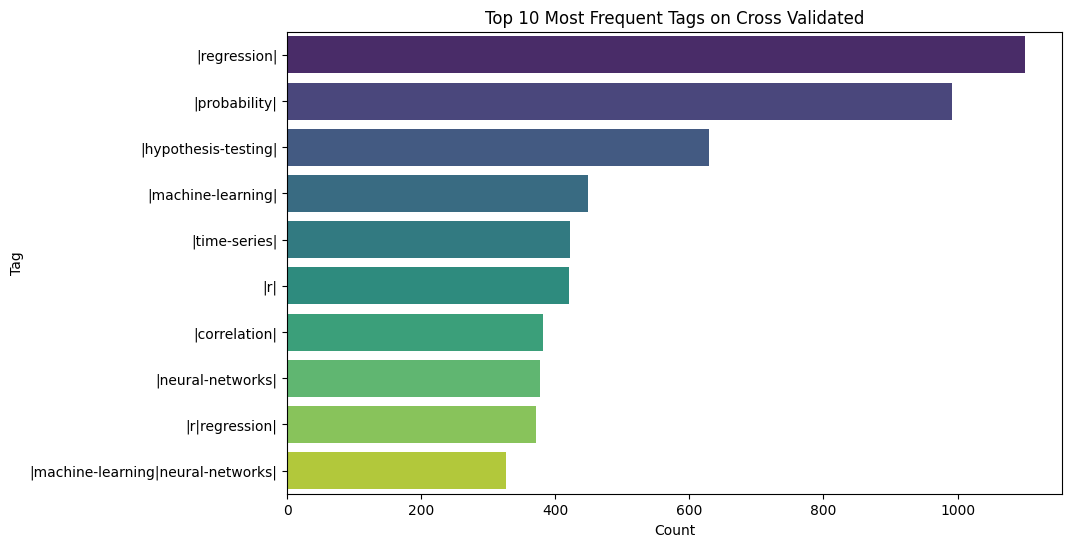

In [20]:
# Extract tags from the Tags column
questions_df['Tags'] = questions_df['Tags'].str.replace('<|>', ' ', regex=True).str.strip().str.split()

# Flatten the list of tags and count their frequency
all_tags = [tag for sublist in questions_df['Tags'].dropna() for tag in sublist]
tag_counts = Counter(all_tags)

# Convert to DataFrame
top_tags_df = pd.DataFrame(tag_counts.most_common(10), columns=['Tag', 'Count'])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Tag', data=top_tags_df, palette='viridis')
plt.title('Top 10 Most Frequent Tags on Cross Validated')
plt.xlabel('Count')
plt.ylabel('Tag')
plt.show()

- Extract tags from the Tags column
- Flatten the list of tags and count their frequency
- Convert to DataFrame
- Plot bar

### Insight: 

The most frequent tags include regression, machine-learning, probability, time-series, and hypothesis-testing. This indicates that these are the most popular topics on Cross Validated.

Users are highly interested in practical and applied statistical methods, particularly those related to data analysis and machine learning. This reflects the growing importance of these fields in academia and industry.

## Distribution of Question Scores

we'll visualize the distribution of question scores to understand the engagement level of questions.

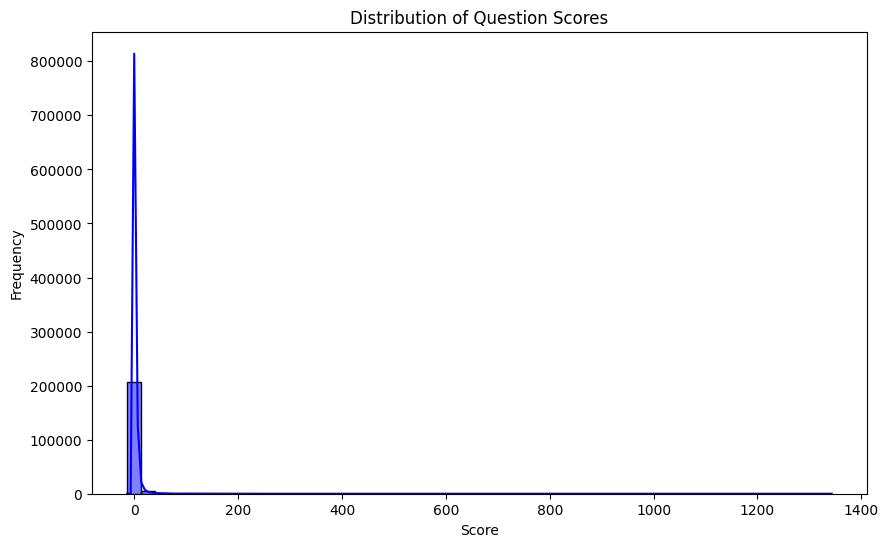

In [21]:
#Plot Histpolot
plt.figure(figsize=(10, 6))
sns.histplot(questions_df['Score'], bins=50, kde=True, color='blue')
plt.title('Distribution of Question Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

### Insight:
The majority of questions have low scores (close to 0), with a long tail of highly upvoted questions.

While most questions receive moderate engagement, a small subset of high-quality or highly relevant questions garners significant attention. This highlights the importance of asking clear, well-formulated questions to maximize engagement.

## Extract Keywords from Titles Using Regex Top 10 Keywords in Titles
We’ll extract keywords from question titles using regex and visualize the most common ones.

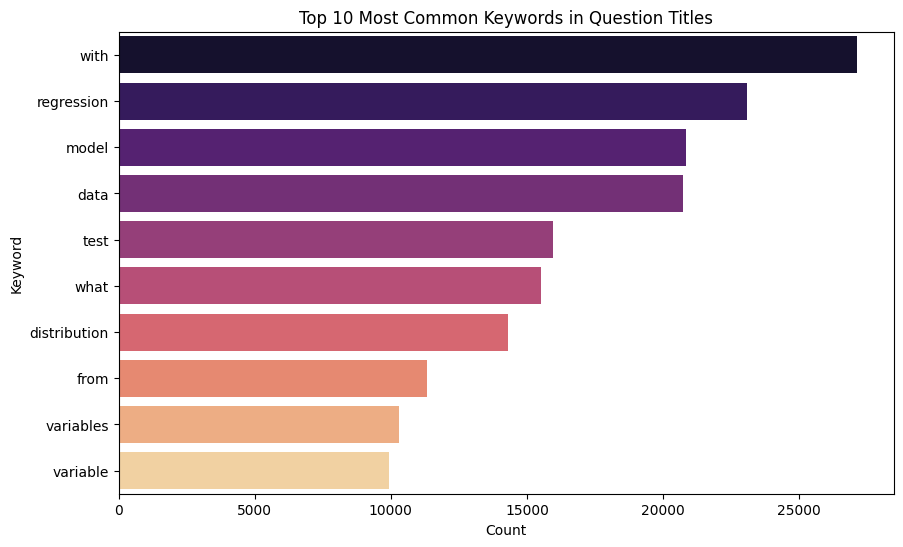

In [22]:
# Define a regex pattern to extract meaningful words (words with 4+ letters)
pattern = r'\b\w{4,}\b'

# Extract keywords from titles
questions_df['Keywords'] = questions_df['Title'].apply(lambda x: re.findall(pattern, str(x).lower()))

# Flatten the list of keywords and count their frequency
all_keywords = [keyword for sublist in questions_df['Keywords'] for keyword in sublist]
keyword_counts = Counter(all_keywords)

# Convert to DataFrame
top_keywords_df = pd.DataFrame(keyword_counts.most_common(10), columns=['Keyword', 'Count'])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Keyword', data=top_keywords_df, palette='magma')
plt.title('Top 10 Most Common Keywords in Question Titles')
plt.xlabel('Count')
plt.ylabel('Keyword')
plt.show()

**step:**

- Define a regex pattern to extract meaningful words (words with 4+ letters)
- Extract keywords from titles
- Flatten the list of keywords and count their frequency
- Convert to DataFrame
- bar plot 



### Insight: 
The most common keywords in question titles include model, data, distribution, regression, and difference.

These keywords reflect the core concerns of the Cross Validated community, such as model building, data analysis, and understanding statistical distributions. This suggests that users are primarily seeking help with practical statistical problems.

## Extract and Visualize Locations from User Profiles

We’ll extract locations from the Users table using regex and visualize the most common ones.

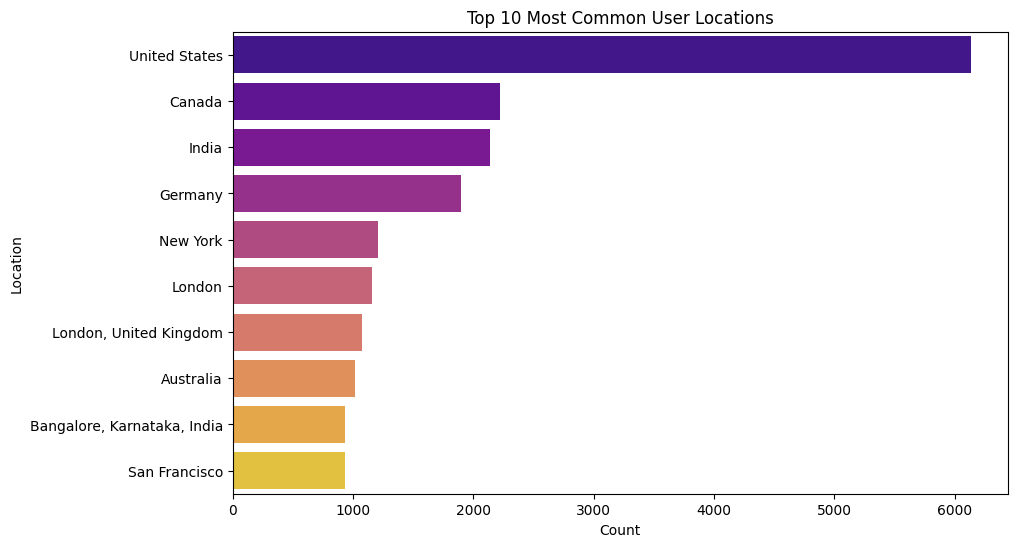

In [23]:
# Define a regex pattern to extract locations ("City, Country")
location_pattern = r'[A-Z][a-z]+(?:,?\s[A-Z][a-z]+)*'

# Extract locations from the 'Location' column
users_df['ExtractedLocation'] = users_df['Location'].apply(lambda x: re.findall(location_pattern, str(x)))

# Flatten the list of locations and count their frequency
all_locations = [location for sublist in users_df['ExtractedLocation'] for location in sublist]
location_counts = Counter(all_locations)

# Convert to DataFrame
top_locations_df = pd.DataFrame(location_counts.most_common(10), columns=['Location', 'Count'])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Location', data=top_locations_df, palette='plasma')
plt.title('Top 10 Most Common User Locations')
plt.xlabel('Count')
plt.ylabel('Location')
plt.show()

**step:**

- Define a regex pattern to extract locations ("City, Country")
- Extract locations from the 'Location' column
- Flatten the list of locations and count their frequency
- Convert to DataFrame
- plot bar


### Insight: 
The most common user locations include United States, India, United Kingdom, Canada, and Germany.

Cross Validated has a global user base, with significant contributions from English-speaking countries and regions with strong academic traditions. This diversity enriches the platform by bringing in a wide range of perspectives and expertise.

## Correlation Between Views and Scores
We’ll explore the relationship between the number of views and the score of questions.

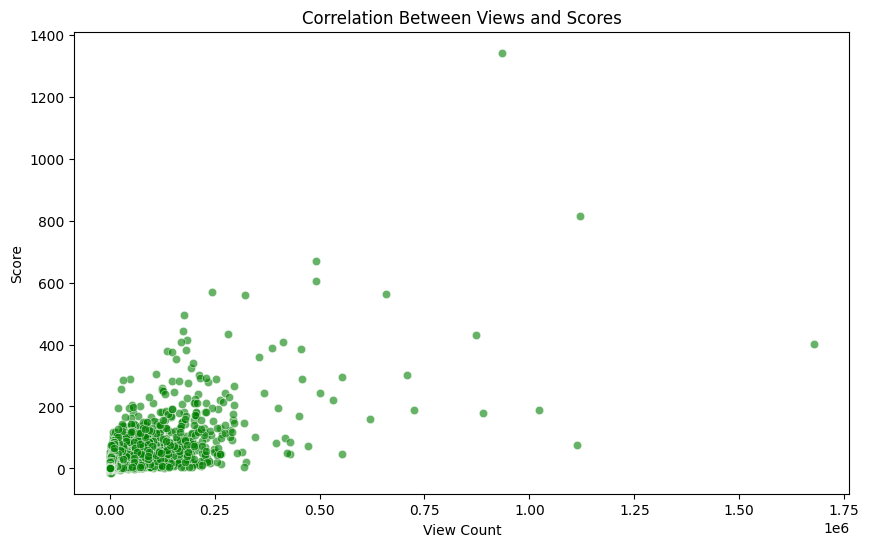

In [106]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ViewCount', y='Score', data=questions_df, alpha=0.6, color='green')
plt.title('Correlation Between Views and Scores')
plt.xlabel('View Count')
plt.ylabel('Score')
plt.show()

### Insight: 
There is a weak positive correlation between the number of views and the score of a question.

While highly viewed questions tend to have higher scores, the relationship is not strong. This suggests that factors other than visibility (question quality, relevance, and timeliness) play a significant role in determining a question's score.


## Most Active Users by Question Count
We can identify the most active users based on the number of questions they have asked.

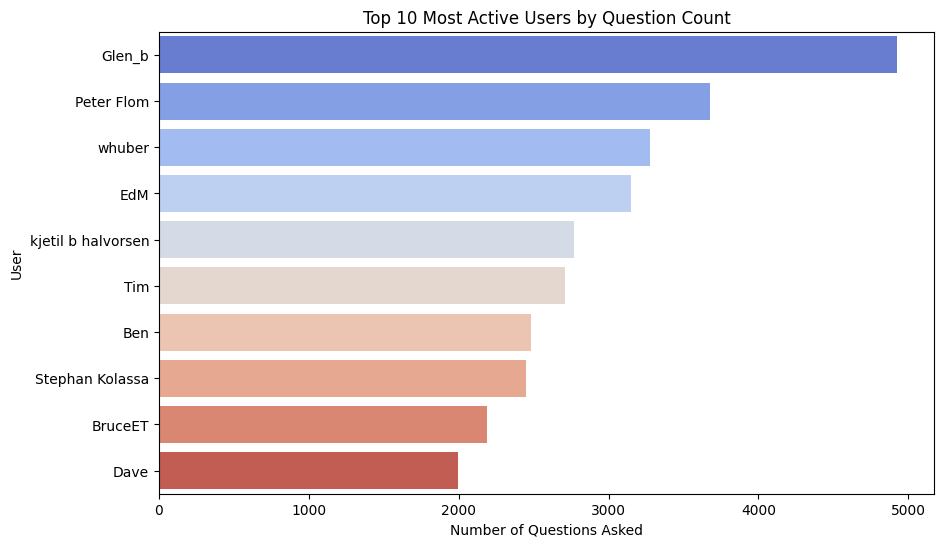

In [107]:
# Group by user and count questions
user_question_count = posts_df['OwnerUserId'].value_counts().reset_index()
user_question_count.columns = ['UserId', 'QuestionCount']

# find the Top 10 most active users
top_users = user_question_count.head(10)

# Merge with Users table to get usernames
top_users = pd.merge(top_users, users_df, left_on='UserId', right_on='Id', how='left')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='QuestionCount', y='DisplayName', data=top_users, palette='coolwarm')
plt.title('Top 10 Most Active Users by Question Count')
plt.xlabel('Number of Questions Asked')
plt.ylabel('User')
plt.show()

**step:**
- Group by user and count questions
- find the Top 10 most active users
- Merge with Users table to get usernames
- Plot barplot

### Insight: 

By grouping the Posts dataset by OwnerUserId (user ID) and counting the number of questions, we can determine which users are the most active in asking questions.


## Distribution of Question Creation Over Time
We can analyze how the number of questions asked has evolved over time.

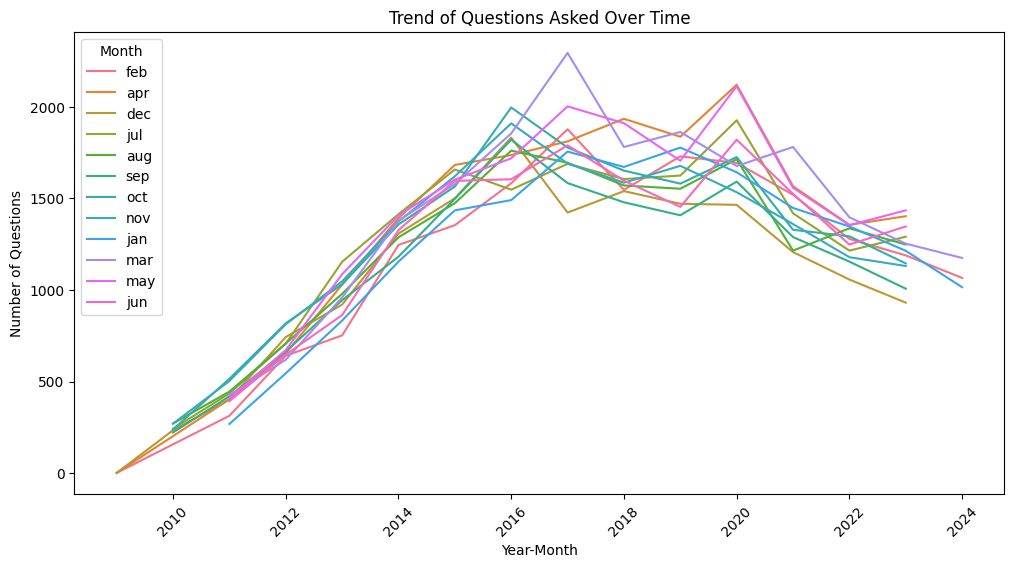

In [108]:
# Extract year and month from CreationDate
questions_df['YearMonth'] = questions_df['CreationDate'].dt.to_period('M')

# Group by YearMonth and count questions
question_trend = questions_df.groupby('YearMonth').size().reset_index(name='QuestionCount')
question_trend["YearMonth"] = question_trend["YearMonth"].astype(str)
question_trend["Year"] = pd.to_datetime(question_trend["YearMonth"]).dt.year
question_trend["Month"] = pd.to_datetime(question_trend["YearMonth"]).dt.strftime('%b').str.lower()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='QuestionCount', data=question_trend, color='blue', hue="Month")
plt.title('Trend of Questions Asked Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Questions')
plt.xticks(rotation=45)
plt.show()

**Step:**
- Extract year and month from CreationDate
- Group by YearMonth and count questions
- line plot
  
### Insight: 
By grouping the CreationDate column by year and month, we can visualize trends in question activity.

## Top 10 Most view Questions

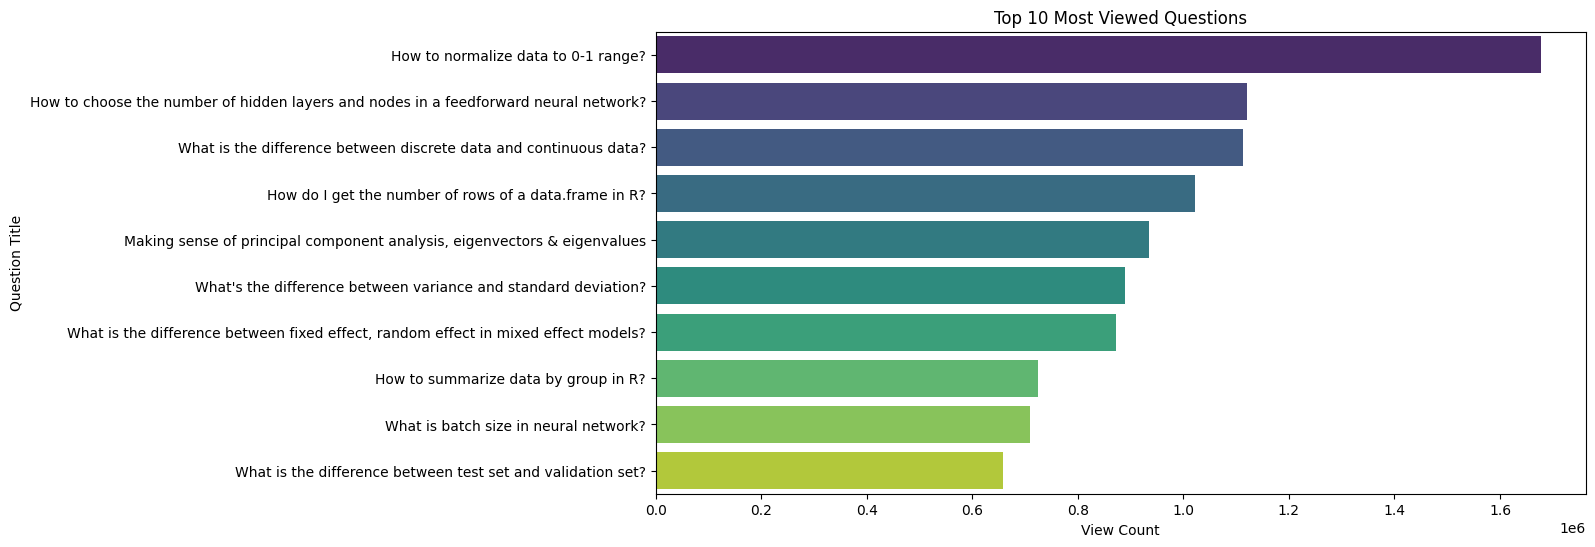

In [109]:
# Sort by ViewCount and select top 10
most_viewed = questions_df.sort_values(by='ViewCount', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='ViewCount', y='Title', data=most_viewed, palette='viridis')
plt.title('Top 10 Most Viewed Questions')
plt.xlabel('View Count')
plt.ylabel('Question Title')
plt.show()

### Insight: 
Most Viewed Questions. We can identify the most viewed questions to understand what topics attract the most attention.
By sorting the Posts dataset by ViewCount, we can find the most viewed questions and their titles.



## Top 10 Tags by Average Question Score

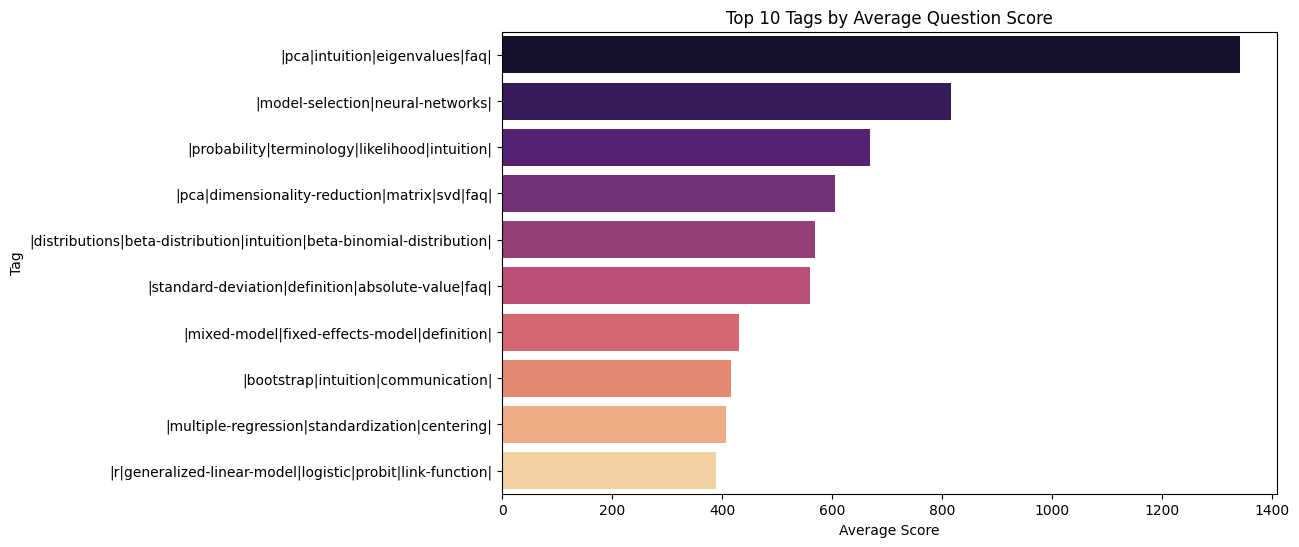

In [110]:
# Explode the Tags column to have one tag per row
exploded_tags = questions_df.explode('Tags')

# Group by tag and calculate average score
tag_scores = exploded_tags.groupby('Tags')['Score'].mean().reset_index()

# Sort and select top 10 tags by average score
top_tag_scores = tag_scores.sort_values(by='Score', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Tags', data=top_tag_scores, palette='magma')
plt.title('Top 10 Tags by Average Question Score')
plt.xlabel('Average Score')
plt.ylabel('Tag')
plt.show()

**Step**
- Explode the Tags column to have one tag per row
- Group by tag and calculate average score
- Sort and select top 10 tags by average score
- Bar plot


### Insight: 
Correlation Between Tags and Question Scores. We can analyze whether certain tags are associated with higher question scores.

By grouping questions by tags and calculating the average score for each tag, we can identify which tags tend to attract higher-quality answers.


## Word Cloud of Common Words in Question Titles

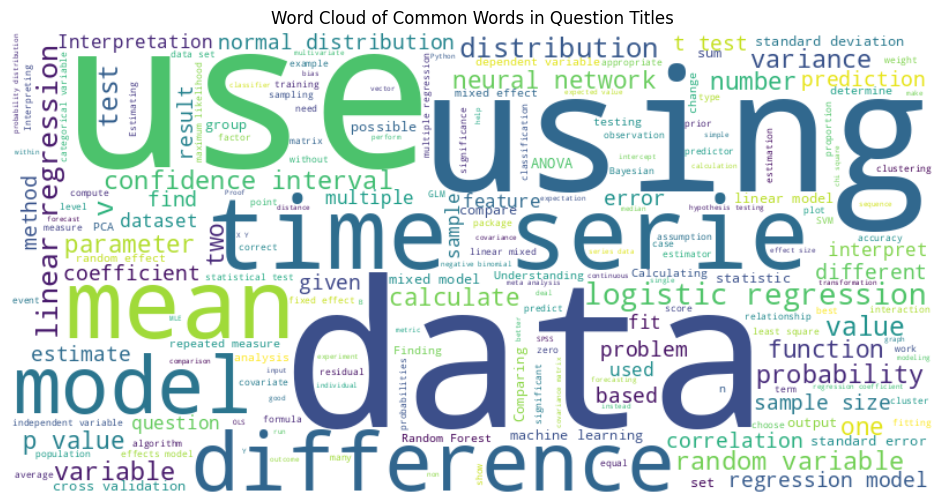

In [24]:
# Combine all titles into a single string
all_titles = ' '.join(questions_df['Title'].dropna())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_titles)

# Plot worldcloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Common Words in Question Titles')
plt.show()

**step:**

- Combine all titles into a single string
- Generate word cloud
- Plot worldcloud

### Insight: 
We can visualize the most common words in question titles using a word cloud.

By extracting words from the Title column and counting their frequency, we can create a word cloud to highlight the most frequently discussed topics.


## Top 10 Questions with Maximum Votes

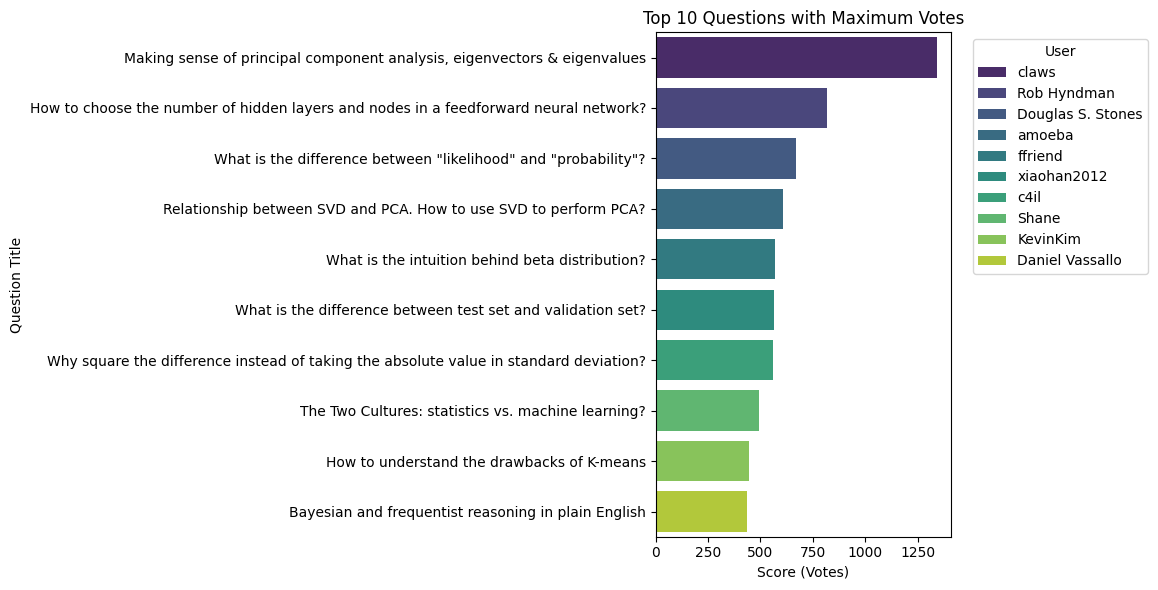

In [42]:
#Finding only Quesiton postedID =1
questions_only = posts_df[posts_df['PostTypeId'] == 1]
# Sort questions by Score in descending order
top_questions = questions_only.sort_values(by='Score', ascending=False).head(10)

# Merge with Users table to get usernames
top_questions_with_users = pd.merge(
    top_questions,
    users_df[['Id', 'DisplayName']],
    left_on='OwnerUserId',
    right_on='Id',
    how='left'
)
# Select relevant columns
top_questions_with_users = top_questions_with_users[['Id_x', 'Title', 'Score', 'DisplayName']]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Score',
    y='Title',
    data=top_questions_with_users,
    hue='DisplayName',
    palette='viridis',
    dodge=False
)
plt.title('Top 10 Questions with Maximum Votes')
plt.xlabel('Score (Votes)')
plt.ylabel('Question Title')
plt.legend(title='User', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Step**

- Finding only Quesiton postedID =1
- Sort questions by Score in descending order top 10
- Merge with Users table to get usernames
- Select relevant columns
- Plot Plot

**Summary Insight**

- **Top 10 Most Frequent Tags:** Bar plot of the most common tags.
- **Distribution of Question Scores:** Histogram of question scores.
- **Top 10 Keywords in Titles:** Bar plot of the most common keywords extracted using regex.
- **Top 10 User Locations:** Bar plot of the most common locations extracted using regex.
- **Correlation Between Views and Scores:** Scatter plot showing the relationship between views and scores.
- **Most Active Users:** Identifies the top users by the number of questions asked.
- **Question Trend Over Time:** Shows how question activity has evolved over the years.
- **Most Viewed Questions:** Highlights the questions that attract the most attention.
- **Tags and Scores:** Reveals which tags are associated with higher-quality questions.
- **Word Cloud:** Visualizes the most common words in question titles.
- **Top 10 Questions with Maximum Votes**
  